# BAB 4 — Skenario 1: Pelatihan Model Baseline (3D-CNN Murni Tanpa Atensi)

Notebook ini melatih model **baseline** sebagai **tolok ukur awal (lower-bound)** sebelum mekanisme atensi diaktifkan.

Model yang digunakan: `AttentiveSkel3D(use_attention=False)` — arsitektur 3D-CNN murni **tanpa** Biomechanical Spatial Prior (BSP) maupun mekanisme atensi apapun. Tensor skeleton mengalir langsung dari langkah reshape ke `conv_block_1`.

> Hasil eksperimen ini akan menjadi **acuan perbandingan** terhadap Skenario 2 (model penuh dengan atensi) untuk mengukur kontribusi nyata modul atensi biomekanikal.

| Parameter | Nilai |
|---|---|
| Skenario | 1 — Baseline (tanpa atensi) |
| Model | `AttentiveSkel3D(use_attention=False)` |
| Optimizer | Adam (`lr=1e-3`) |
| Loss | CrossEntropyLoss |
| Epochs | 100 |
| Batch size | 16 |
| Split | 70% train / 15% val / 15% test |
| Output model | `baseline_3dcnn_model.pth` |

In [2]:
# ============================================================
# Cell 2: Import library dan konfigurasi device
# ============================================================
import sys
from pathlib import Path

# Tambahkan root proyek ke sys.path agar modul src/ dapat diimport
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Modul proyek
from src.data.dataset import create_dataloaders
from src.models.model_3dcnn import AttentiveSkel3D, count_parameters
from src.models.train import train_model

# Konfigurasi device: gunakan GPU jika tersedia, fallback ke CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] PyTorch  : {torch.__version__}")
print(f"[INFO] Device   : {device}")
if device.type == "cuda":
    print(f"[INFO] GPU      : {torch.cuda.get_device_name(0)}")

[INFO] PyTorch  : 2.5.1
[INFO] Device   : cuda
[INFO] GPU      : NVIDIA GeForce RTX 3060 Ti


In [3]:
# ============================================================
# Cell 3: Setup DataLoader — Muat dataset dari manifest CSV
# ============================================================
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"

train_loader, val_loader, test_loader = create_dataloaders(
    csv_file    = MANIFEST_PATH,
    batch_size  = 16,
    train_ratio = 0.70,
    val_ratio   = 0.15,
    num_workers = 0,       # 0 di Windows untuk menghindari masalah multiprocessing
    random_seed = 42,
)

# Hitung jumlah sampel tiap split
n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)
n_total = n_train + n_val + n_test

print(f"[INFO] Total sampel       : {n_total}")
print(f"[INFO] Train / Val / Test : {n_train} / {n_val} / {n_test}")
print(f"[INFO] Iterasi per epoch  : {len(train_loader)}")

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch
[INFO] Total sampel       : 487
[INFO] Train / Val / Test : 340 / 73 / 74
[INFO] Iterasi per epoch  : 21


In [4]:
# ============================================================
# Cell 4: Inisialisasi Model Baseline, Loss Function, dan Optimizer
# ============================================================

# Inisialisasi model dengan use_attention=False → 3D-CNN murni tanpa BSP.
# Seluruh jalur atensi (BSP, Spatial Attention, Temporal Attention) dibypass.
model_baseline = AttentiveSkel3D(
    num_classes   = 2,      # 0 = Gerakan Benar, 1 = Gerakan Salah
    use_attention = False,  # ← KUNCI: matikan seluruh jalur atensi
).to(device)

total_params = count_parameters(model_baseline)
print(f"[INFO] Mode              : BASELINE (3D-CNN Murni, tanpa atensi)")
print(f"[INFO] use_attention     : {model_baseline.use_attention}")
print(f"[INFO] Parameter trainable: {total_params:,}")

# CrossEntropyLoss: mencakup Softmax secara internal,
# model cukup menghasilkan logit mentah.
criterion = nn.CrossEntropyLoss()

# Adam lr=1e-3 adalah titik awal standar untuk dataset kecil (~487 sampel)
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)

print(f"[INFO] Loss function     : CrossEntropyLoss")
print(f"[INFO] Optimizer         : Adam (lr=1e-3)")

[INFO] Mode              : BASELINE (3D-CNN Murni, tanpa atensi)
[INFO] use_attention     : False
[INFO] Parameter trainable: 101,891
[INFO] Loss function     : CrossEntropyLoss
[INFO] Optimizer         : Adam (lr=1e-3)


In [5]:
# ============================================================
# Cell 5: Training Loop — Jalankan pelatihan model baseline
# ============================================================
# Simpan model terbaik dengan nama eksklusif agar tidak menimpa
# model AttentiveSkel-3D penuh di skenario berikutnya.
SAVE_DIR      = PROJECT_ROOT / "models" / "saved_models"
SAVE_FILENAME = "baseline_3dcnn_model.pth"

print(f"[INFO] Model terbaik akan disimpan ke: {SAVE_DIR / SAVE_FILENAME}\n")

# train_model akan:
#   1. Melatih selama num_epochs epoch
#   2. Evaluasi validasi di setiap akhir epoch
#   3. Simpan bobot terbaik (val_loss terkecil) ke disk secara otomatis
#   4. Return dict history berisi semua metric per epoch
history = train_model(
    model         = model_baseline,
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    optimizer     = optimizer,
    num_epochs    = 100,
    device        = device,
    save_dir      = SAVE_DIR,
    save_filename = SAVE_FILENAME,
    verbose       = True,
)

print(f"\n[DONE] Epoch terbaik    : {history['best_epoch']}")
print(f"[DONE] Val Loss terbaik : {history['best_val_loss']:.4f}")
print(f"[DONE] Val Acc terbaik  : {history['val_acc'][history['best_epoch']-1]*100:.2f}%")
print(f"[DONE] Model disimpan di: {SAVE_DIR / SAVE_FILENAME}")

[INFO] Model terbaik akan disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\baseline_3dcnn_model.pth

  Memulai pelatihan AttentiveSkel-3D
  Device    : cuda
  Epochs    : 100
  Save path : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\baseline_3dcnn_model.pth
Epoch [  1/100] ✓ | Train Loss: 0.5164 | Train Acc:  78.87% | Val Loss: 0.4325 | Val Acc:  83.56% | Waktu: 4.2s
Epoch [  2/100]   | Train Loss: 0.3509 | Train Acc:  86.31% | Val Loss: 0.6037 | Val Acc:  76.71% | Waktu: 0.4s
Epoch [  3/100] ✓ | Train Loss: 0.2793 | Train Acc:  90.48% | Val Loss: 0.3241 | Val Acc:  87.67% | Waktu: 0.2s
Epoch [  4/100]   | Train Loss: 0.2824 | Train Acc:  88.69% | Val Loss: 0.4854 | Val Acc:  80.82% | Waktu: 0.2s
Epoch [  5/100] ✓ | Train Loss: 0.2686 | Train Acc:  88.69% | Val Loss: 0.2855 | Val Acc:  87.67% | Waktu: 0.2s
Epoch [  6/100]   | Train Loss: 0.2474 | Train Acc:  88.99% | Val Loss: 0.2979 | Val Acc: 

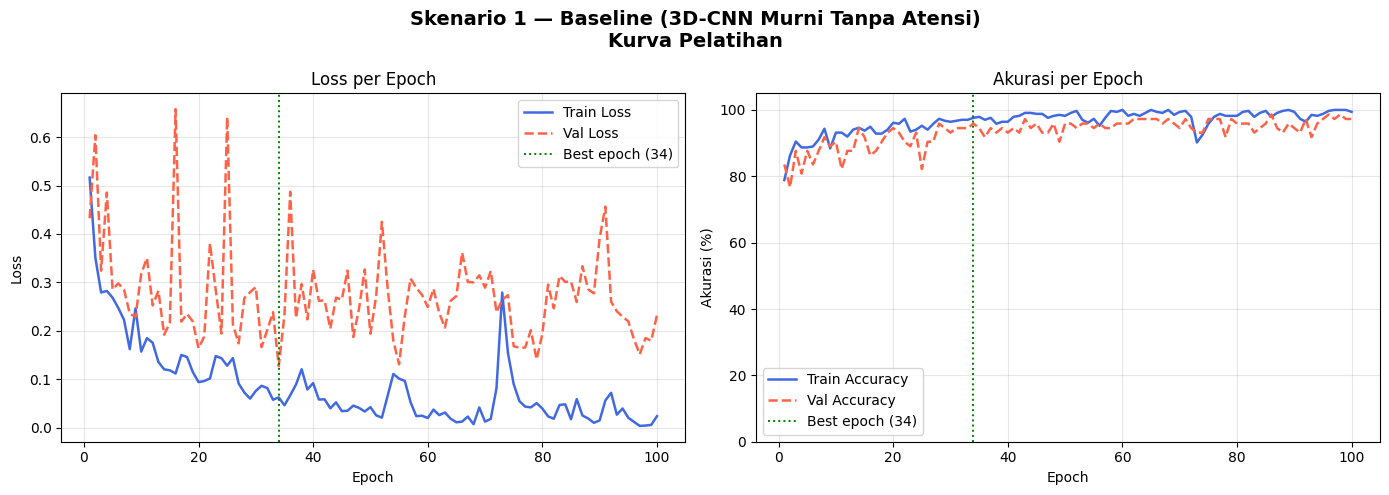


  RINGKASAN HASIL — BASELINE SKENARIO 1
  Epoch terbaik               : 34
  Val Loss terbaik            : 0.1271
  Val Accuracy @ best epoch   : 95.89%
  Train Accuracy (epoch akhir): 99.40%
  Val Accuracy  (epoch akhir) : 97.26%
  Kurva tersimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\baseline_training_curve.png


In [6]:
# ============================================================
# Cell 6: Visualisasi — Plot Kurva Loss dan Akurasi Pelatihan
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
best_ep      = history["best_epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Skenario 1 — Baseline (3D-CNN Murni Tanpa Atensi)\nKurva Pelatihan",
    fontsize=14, fontweight="bold"
)

# ── Plot kiri: Kurva Loss ──────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history["train_loss"],
         label="Train Loss", color="royalblue", linewidth=1.8)
ax1.plot(epochs_range, history["val_loss"],
         label="Val Loss", color="tomato", linewidth=1.8, linestyle="--")
ax1.axvline(x=best_ep, color="green", linestyle=":", linewidth=1.4,
            label=f"Best epoch ({best_ep})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss per Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot kanan: Kurva Akurasi ──────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]],
         label="Train Accuracy", color="royalblue", linewidth=1.8)
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],
         label="Val Accuracy", color="tomato", linewidth=1.8, linestyle="--")
ax2.axvline(x=best_ep, color="green", linestyle=":", linewidth=1.4,
            label=f"Best epoch ({best_ep})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Akurasi (%)")
ax2.set_title("Akurasi per Epoch")
ax2.legend()
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Simpan kurva ke folder models/saved_models/
CURVE_PATH = SAVE_DIR / "baseline_training_curve.png"
plt.savefig(CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()

# ── Ringkasan numerik ──────────────────────────────────────
best_val_acc    = history["val_acc"][best_ep - 1] * 100
final_train_acc = history["train_acc"][-1] * 100
final_val_acc   = history["val_acc"][-1]   * 100

print(f"\n{'='*55}")
print(f"  RINGKASAN HASIL — BASELINE SKENARIO 1")
print(f"{'='*55}")
print(f"  Epoch terbaik               : {best_ep}")
print(f"  Val Loss terbaik            : {history['best_val_loss']:.4f}")
print(f"  Val Accuracy @ best epoch   : {best_val_acc:.2f}%")
print(f"  Train Accuracy (epoch akhir): {final_train_acc:.2f}%")
print(f"  Val Accuracy  (epoch akhir) : {final_val_acc:.2f}%")
print(f"{'='*55}")
print(f"  Kurva tersimpan : {CURVE_PATH}")